<a href="https://colab.research.google.com/github/pepzzz19-crypto/nhan-dien-mon-an/blob/main/vietnamese_dishes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import gdown
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

Found 157 images belonging to 98 classes.
Found 14 images belonging to 98 classes.
Món ăn phát hiện được: ['385533509', '387531040', '406581968', '448903294', '453178253', '456462733', '484632487', '494204873', '503283280', '526527256', '546273489', '546391274', '552620627', '557635127', '559222688', '559556417', '559587158', '567209606', '568688279', '572269115', '574385533', '575658391', 'Gemini', 'Screenshot', 'gen-h-z7476401126562', 'gen-h-z7503080606889', 'gen-h-z7748888996860', 'gen-h-z7748889020187', 'gen-h-z7842964760933', 'gen-h-z7842964816065', 'gen-h-z7873830473077', 'gen-h-z7873830509688', 'gen-h-z7873830543098', 'gen-h-z7873830577141', 'gen-h-z7873830608956', 'gen-h-z7873830643486', 'gen-h-z7873830673726', 'gen-h-z7873830710841', 'gen-h-z7873830809975', 'gen-h-z7873830852516', 'gen-h-z7873830895369', 'gen-h-z7873830937718', 'gen-h-z7873830979293', 'gen-h-z7873831024224', 'gen-h-z7873831085667', 'gen-h-z7873831137266', 'gen-h-z7873831178837', 'gen-h-z7873831220291', 'gen-h-

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Bắt đầu huấn luyện mô hình nhận diện món ăn Việt...
Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.0821 - loss: 11.0754 

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


5/5 ━━━━━━━━━━━━━━━━━━━━ 83s 15s/step - accuracy: 0.0701 - loss: 10.2201 - val_accuracy: 0.9286 - val_loss: 2.9917
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.3376 - loss: 3.9019 - val_accuracy: 0.9286 - val_loss: 2.4958
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.3376 - loss: 3.6185 - val_accuracy: 0.9286 - val_loss: 1.9546
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.3376 - loss: 3.4287 - val_accuracy: 0.9286 - val_loss: 2.5182
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.3376 - loss: 3.3405 - val_accuracy: 0.9286 - val_loss: 3.0044
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.3376 - loss: 3.2790 - val_accuracy: 0.9286 - val_loss: 2.4508
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.3376 - loss: 3.2367 - val_accuracy: 0.8571 - val_loss: 2.6227
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.3376 - loss: 3.0911 - val_accuracy: 0.8571 - val_loss: 2.6157
Epoch 9/20
5/5 ━━━━━━━━

Đã lưu mô hình thành công!


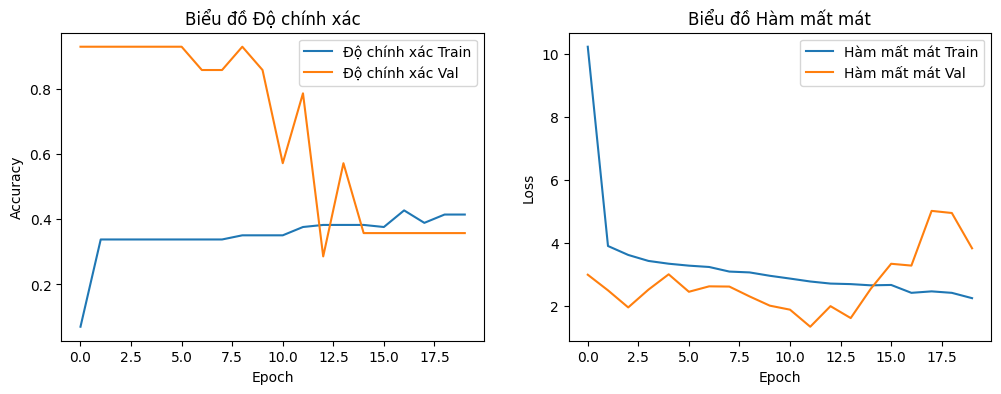

In [17]:
DRIVE_FOLDER_URL = "https://drive.google.com/drive/folders/1qTTEePzO1RzhLZplxaRMzielXnZicdUI?usp=sharing"
# Removed gdown download as Google Drive is now mounted
DATA_DIR = '/content/drive/My Drive/vietnamese dishes' # Corrected to match the actual folder name

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

train_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

val_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

num_classes = train_generator.num_classes
class_labels = list(train_generator.class_indices.keys())
print(f"Món ăn phát hiện được: {class_labels}")
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Bắt đầu huấn luyện mô hình nhận diện món ăn Việt...")
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator
)

model.save('vietnamese_dishes_model.h5')
print("Đã lưu mô hình thành công!")
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Độ chính xác Train')
plt.plot(history.history['val_accuracy'], label='Độ chính xác Val')
plt.title('Biểu đồ Độ chính xác')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Hàm mất mát Train')
plt.plot(history.history['val_loss'], label='Hàm mất mát Val')
plt.title('Biểu đồ Hàm mất mát')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

### Tự động sắp xếp lại thư mục dữ liệu bằng Python

Để tự động hóa quá trình sắp xếp các tệp hình ảnh vào các thư mục con theo lớp (class), bạn cần một cách để xác định lớp của mỗi hình ảnh từ tên tệp của nó. Script dưới đây cung cấp một ví dụ về cách bạn có thể thực hiện điều này. Bạn sẽ cần điều chỉnh hàm `get_class_name_from_filename` để phù hợp với quy ước đặt tên tệp của bạn.

**Ví dụ về các quy ước đặt tên tệp phổ biến:**
*   **`TenLop_tenhinh.jpg`**: Ví dụ `Pho_001.jpg`, `BunCha_A1.png`
*   **`tenhinh_TenLop.jpeg`**: Ví dụ `image001_BanhMi.jpeg`

Trong ví dụ này, tôi sẽ giả định rằng tên lớp là phần đầu tiên của tên tệp, được phân tách bằng dấu gạch dưới (`_`). Nếu quy ước của bạn khác, hãy sửa đổi hàm `get_class_name_from_filename` cho phù hợp.

In [15]:
import os
import shutil

# DATA_DIR đã được định nghĩa ở trên: '/content/drive/My Drive/vietnamese dishes'

def get_class_name_from_filename(filename):
    """
    Hàm này cố gắng trích xuất tên lớp từ tên tệp.
    Bạn CẦN điều chỉnh hàm này để phù hợp với quy ước đặt tên tệp của bạn.
    """
    # Ví dụ 1: Tên lớp là phần đầu tiên, phân tách bằng dấu gạch dưới (ví dụ: 'Pho_001.jpg' -> 'Pho')
    if '_' in filename:
        return filename.split('_')[0]
    # Ví dụ 2: Nếu tên tệp không có dấu gạch dưới, có thể bạn cần một ánh xạ khác
    # hoặc tên tệp chính là tên lớp (ít phổ biến khi có nhiều ảnh trong 1 lớp).
    # Ví dụ: Nếu tệp là 'BanhMi.jpg' và đó là lớp 'BanhMi'
    # return os.path.splitext(filename)[0]

    # Nếu không thể xác định tên lớp, trả về None hoặc một giá trị mặc định để xử lý lỗi.
    print(f"Cảnh báo: Không thể xác định tên lớp cho tệp: {filename}. Vui lòng sửa đổi hàm `get_class_name_from_filename`.")
    return "unknown_class" # Hoặc raise an error

def organize_dataset(base_dir):
    if not os.path.exists(base_dir):
        print(f"Thư mục '{base_dir}' không tồn tại. Vui lòng kiểm tra lại đường dẫn.")
        return

    print(f"Bắt đầu tổ chức lại dữ liệu trong: {base_dir}")

    files_to_move = []
    for item in os.listdir(base_dir):
        item_path = os.path.join(base_dir, item)
        if os.path.isfile(item_path):
            files_to_move.append(item_path)
        elif os.path.isdir(item_path):
            print(f"Bỏ qua thư mục con hiện có: {item}")

    if not files_to_move:
        print("Không tìm thấy tệp hình ảnh nào trong thư mục gốc để di chuyển.")
        return

    for file_path in files_to_move:
        filename = os.path.basename(file_path)
        class_name = get_class_name_from_filename(filename)

        if class_name:
            target_class_dir = os.path.join(base_dir, class_name)
            os.makedirs(target_class_dir, exist_ok=True)

            target_file_path = os.path.join(target_class_dir, filename)
            try:
                shutil.move(file_path, target_file_path)
                # print(f"Di chuyển '{filename}' đến '{target_class_dir}'")
            except Exception as e:
                print(f"Lỗi khi di chuyển tệp '{filename}': {e}")
        else:
            print(f"Không thể di chuyển tệp '{filename}' vì không xác định được tên lớp.")

    print("Quá trình tổ chức lại dữ liệu hoàn tất.")
    print("Vui lòng kiểm tra cấu trúc thư mục mới.")

# Chạy hàm tổ chức lại dữ liệu
organize_dataset(DATA_DIR)


Bắt đầu tổ chức lại dữ liệu trong: /content/drive/My Drive/vietnamese dishes
Bỏ qua thư mục con hiện có: wallpaperflare.com
Bỏ qua thư mục con hiện có: unknown_class
Bỏ qua thư mục con hiện có: Screenshot
Bỏ qua thư mục con hiện có: z7192834415763
Bỏ qua thư mục con hiện có: z7192859267594
Bỏ qua thư mục con hiện có: z7192868680654
Bỏ qua thư mục con hiện có: 575658391
Bỏ qua thư mục con hiện có: 567209606
Bỏ qua thư mục con hiện có: Gemini
Bỏ qua thư mục con hiện có: 552620627
Bỏ qua thư mục con hiện có: 559222688
Bỏ qua thư mục con hiện có: 526527256
Bỏ qua thư mục con hiện có: 546273489
Bỏ qua thư mục con hiện có: 387531040
Bỏ qua thư mục con hiện có: 484632487
Bỏ qua thư mục con hiện có: 557635127
Bỏ qua thư mục con hiện có: 453178253
Bỏ qua thư mục con hiện có: 546391274
Bỏ qua thư mục con hiện có: 494204873
Bỏ qua thư mục con hiện có: 503283280
Bỏ qua thư mục con hiện có: 574385533
Bỏ qua thư mục con hiện có: 559587158
Bỏ qua thư mục con hiện có: 572269115
Bỏ qua thư mục con hiện

### Kiểm tra cấu trúc thư mục sau khi sắp xếp

Sau khi chạy script trên, hãy chạy ô mã dưới đây để xác nhận rằng các tệp đã được di chuyển thành công vào các thư mục con tương ứng.

In [16]:
import os

print(f"Kiểm tra cấu trúc thư mục trong '{DATA_DIR}':")
if os.path.exists(DATA_DIR):
    for item in os.listdir(DATA_DIR):
        item_path = os.path.join(DATA_DIR, item)
        if os.path.isdir(item_path):
            # Đếm số lượng tệp trong thư mục con, bỏ qua các thư mục con khác
            files_in_subdir = [f for f in os.listdir(item_path) if os.path.isfile(os.path.join(item_path, f))]
            print(f"  [Thư mục lớp] {item}/ (chứa {len(files_in_subdir)} tệp)")
        else:
            print(f"  [Tệp trực tiếp] {item} (Nên là 0 tệp này sau khi tổ chức lại)")
    if not os.listdir(DATA_DIR):
        print("Thư mục dữ liệu gốc trống rỗng hoặc không có gì bên trong.")
else:
    print(f"Thư mục dữ liệu '{DATA_DIR}' không tồn tại. Vui lòng kiểm tra lại đường dẫn.")

print("Nếu cấu trúc thư mục đã chính xác, bạn có thể chạy lại các ô mã bắt đầu từ `ImageDataGenerator`.")


Kiểm tra cấu trúc thư mục trong '/content/drive/My Drive/vietnamese dishes':
  [Thư mục lớp] wallpaperflare.com/ (chứa 2 tệp)
  [Thư mục lớp] unknown_class/ (chứa 70 tệp)
  [Thư mục lớp] Screenshot/ (chứa 2 tệp)
  [Thư mục lớp] z7192834415763/ (chứa 1 tệp)
  [Thư mục lớp] z7192859267594/ (chứa 1 tệp)
  [Thư mục lớp] z7192868680654/ (chứa 1 tệp)
  [Thư mục lớp] 575658391/ (chứa 1 tệp)
  [Thư mục lớp] 567209606/ (chứa 1 tệp)
  [Thư mục lớp] Gemini/ (chứa 6 tệp)
  [Thư mục lớp] 552620627/ (chứa 2 tệp)
  [Thư mục lớp] 559222688/ (chứa 1 tệp)
  [Thư mục lớp] 526527256/ (chứa 1 tệp)
  [Thư mục lớp] 546273489/ (chứa 1 tệp)
  [Thư mục lớp] 387531040/ (chứa 1 tệp)
  [Thư mục lớp] 484632487/ (chứa 1 tệp)
  [Thư mục lớp] 557635127/ (chứa 1 tệp)
  [Thư mục lớp] 453178253/ (chứa 1 tệp)
  [Thư mục lớp] 546391274/ (chứa 1 tệp)
  [Thư mục lớp] 494204873/ (chứa 1 tệp)
  [Thư mục lớp] 503283280/ (chứa 1 tệp)
  [Thư mục lớp] 574385533/ (chứa 1 tệp)
  [Thư mục lớp] 559587158/ (chứa 1 tệp)
  [Thư mục lớp] 